In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.isna().sum()

,0
review,0
sentiment,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [5]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
print(df['review'].iloc[0])
print(df['review'].iloc[1])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [7]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("Average Review Length:", df['review_length'].mean())

Average Review Length: 231.15694


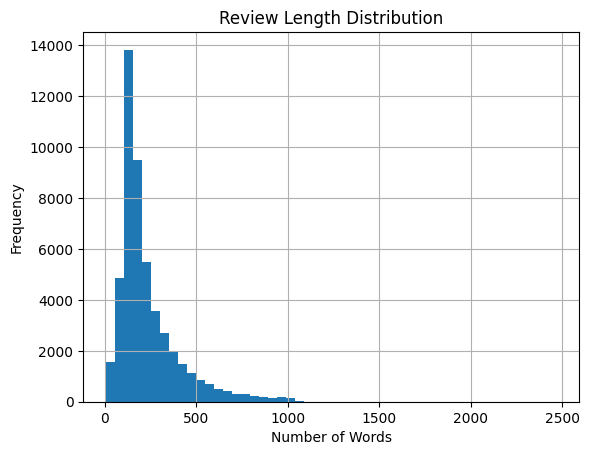

In [8]:
import matplotlib.pyplot as plt

df['review_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
df['review'] = df['review'].str.lower()

In [10]:
import re

def remove_html(text):
    return re.sub(r'<.*?>', '', text)

df['review'] = df['review'].apply(remove_html)

In [11]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['review'] = df['review'].apply(remove_punctuation)

In [12]:
df['tokens'] = df['review'].apply(lambda x: x.split())

In [15]:
import nltk
nltk.download('all')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200
X = pad_sequences(sequences, maxlen=max_len)

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Limit vocabulary size (top 5000 words)
tokenizer = Tokenizer(num_words=5000)

# Fit on text data
tokenizer.fit_on_texts(df['review'])

In [19]:
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 223804


In [20]:
sequences = tokenizer.texts_to_sequences(df['review'])

print(sequences[0])

[27, 4, 1, 77, 1929, 42, 1058, 11, 100, 144, 39, 507, 3339, 393, 457, 25, 3147, 33, 22, 204, 13, 10, 6, 593, 46, 582, 14, 87, 145, 11, 3221, 68, 41, 3339, 12, 28, 2, 131, 4, 584, 60, 282, 7, 204, 35, 1, 661, 137, 1724, 68, 10, 6, 20, 3, 117, 15, 1, 38, 10, 117, 2479, 54, 14, 5, 1457, 381, 38, 584, 28, 6, 3383, 7, 1, 350, 337, 4, 1, 6, 461, 3339, 13, 11, 6, 1, 344, 5, 1, 2539, 1056, 8, 2603, 1365, 19, 533, 32, 4683, 2495, 4, 1, 1197, 112, 30, 1, 24, 2950, 2, 405, 37, 6, 20, 317, 19, 1, 3712, 533, 6, 341, 5, 2439, 2, 328, 2, 22, 108, 224, 56, 124, 1, 267, 1291, 4, 1, 117, 6, 663, 5, 1, 185, 11, 8, 260, 112, 77, 254, 547, 2963, 818, 177, 1262, 4291, 15, 2473, 1092, 818, 1400, 818, 146, 970, 180, 1, 87, 393, 9, 119, 200, 3221, 68, 13, 37, 1569, 8, 12, 2188, 9, 395, 124, 9, 12, 1540, 15, 8, 17, 13, 9, 275, 49, 9, 1454, 3, 1240, 15, 3339, 2, 181, 5, 1, 317, 2070, 4, 2081, 584, 20, 39, 584, 17, 4907, 25, 2919, 43, 15, 3, 489, 19, 611, 2, 74, 238, 14, 8, 72, 746, 808, 105, 655, 76, 1197, 663, 

In [21]:
for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

the : 1
and : 2
a : 3
of : 4
to : 5
is : 6
in : 7
it : 8
i : 9
this : 10


In [25]:
index_word = tokenizer.index_word

print(index_word[1])

the


In [26]:
# Find max length
max_length = max(len(seq) for seq in sequences)

print("Maximum Review Length:", max_length)

Maximum Review Length: 1954


In [27]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set fixed length (you can choose smaller than max for efficiency)
max_len = 200

X = pad_sequences(sequences, maxlen=max_len, padding='pre')

In [28]:
print(X.shape)

(50000, 200)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [30]:
vocab_size = 5000   # same as tokenizer
embedding_dim = 64  # size of word vectors
max_len = 200       # sequence length

model = Sequential()

# 🔸 Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))

# 🔸 Simple RNN Layer
model.add(SimpleRNN(64, activation='tanh'))

# 🔸 Dense Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
from sklearn.model_selection import train_test_split

# Labels (convert positive/negative → 1/0)
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6336 - loss: 0.6212 - val_accuracy: 0.6885 - val_loss: 0.6753
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8153 - loss: 0.4114 - val_accuracy: 0.8214 - val_loss: 0.4109
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8984 - loss: 0.2571 - val_accuracy: 0.8475 - val_loss: 0.3968
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9460 - loss: 0.1521 - val_accuracy: 0.8305 - val_loss: 0.4660
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9779 - loss: 0.0695 - val_accuracy: 0.8173 - val_loss: 0.5825


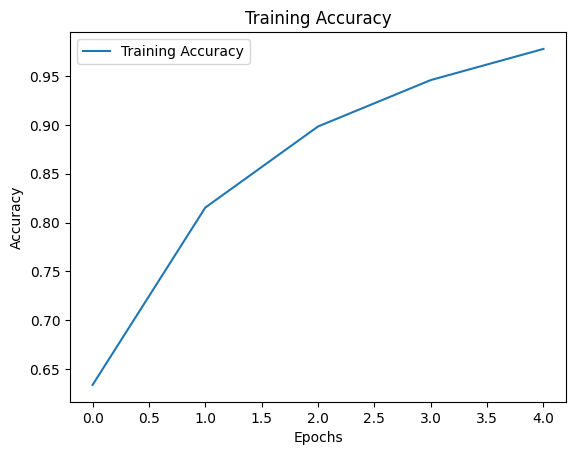

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

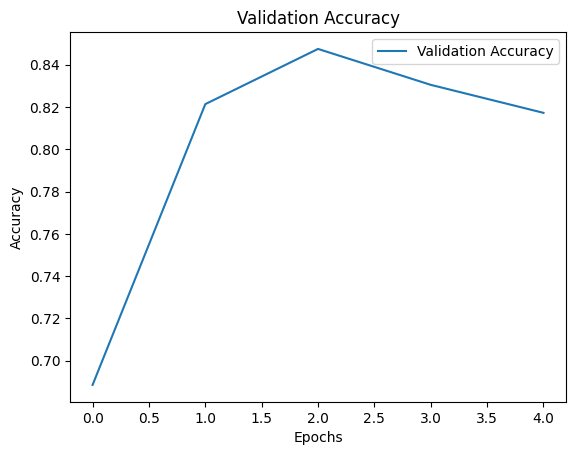

In [37]:
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

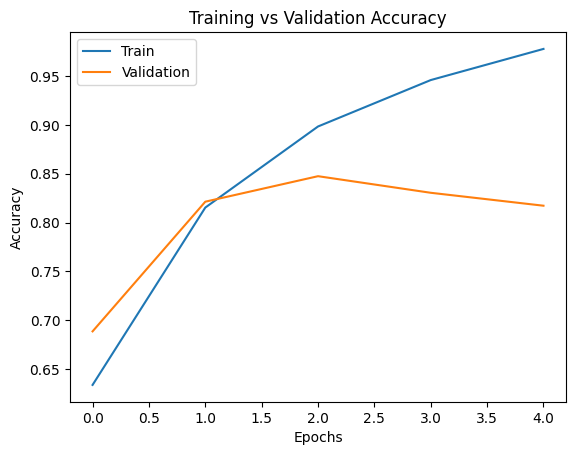

In [38]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [39]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8295 - loss: 0.5588
Test Accuracy: 0.8295000195503235


In [40]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4036  925]
 [ 780 4259]]


In [42]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8215663580246914
Recall: 0.8452073824171462


In [43]:
import numpy as np

misclassified = np.where(y_test != y_pred.flatten())[0]

for i in misclassified[:5]:
    print("Review:", df['review'].iloc[i])
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i])
    print("-"*50)

Review: a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done
Actual: 1 Predicted: [0]
------------------------------

In [44]:
import re
import string
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [45]:
def predict_review(review):
    # Preprocess
    processed = preprocess_text(review)

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([processed])

    # Padding
    padded = pad_sequences(seq, maxlen=200)

    # Predict
    prob = model.predict(padded)[0][0]

    # Output
    sentiment = "Positive" if prob > 0.5 else "Negative"

    return sentiment, round(float(prob), 2)

In [46]:
reviews = [
    "This product quality is amazing",
    "Worst experience ever, very bad service",
    "The movie was not bad actually",
    "I love the design but performance is terrible",
    "It is okay, nothing special"
]

for r in reviews:
    sentiment, confidence = predict_review(r)
    print("Review:", r)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", confidence)
    print("-"*50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
Review: This product quality is amazing
Predicted Sentiment: Positive
Confidence: 1.0
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Review: Worst experience ever, very bad service
Predicted Sentiment: Negative
Confidence: 0.01
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Review: The movie was not bad actually
Predicted Sentiment: Positive
Confidence: 0.86
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Review: I love the design but performance is terrible
Predicted Sentiment: Positive
Confidence: 0.52
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Review: It is okay, nothing special
Predicted Sentiment: Positive
Confidence: 0.99
--------------------------------------------------
